Utilizzando il dataset iris, replica l'esercitazione pratica in Python:
- Effettuare la standarizzazione dei dati
- Plottare l'Elbow Method e stabilire il numero k di clusters
- Addestrare un modello k-Means usando i parametri:
    * n_clusters=k
    * init="k-means++"
    * n_init=10
    * random_state=42
- Ridurre i dati con PCA a n_components=2 e subplottare:
    * i dati colorati in base alla loro vera classe
    * i dati colorati in base ai cluster trovati e i relativi centroidi

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [ ]:
iris=load_iris() #dataset
X,y=iris.data, iris.target #X=matrice delle feature y= tipi di iris, sono le label
feature_names=iris.feature_names #nomi delle colonne
n_feature=len(feature_names)
print (X.shape)
print(feature_names)

(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
4


In [6]:
scaler=StandardScaler()
X_std=scaler.fit_transform(X)

In [22]:
#preparazione del metodo del gomito
wcss=[] #crea lista vuota (più i punti sono vicini al loro centroide, più WCSS è bassa)
k_values=range(1,n_feature+1)  #crea i valori k in base al numero di feature
for k in k_values:  #per ogni k (da 1 a 10) provo il kmeans
    kmeans=KMeans(n_clusters=k,init='k-means++',random_state=42, n_init=10) #creo il metodo kmeans con k cluster
    kmeans.fit(X_std) #addestro il modello
    wcss.append(kmeans.inertia_)

c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

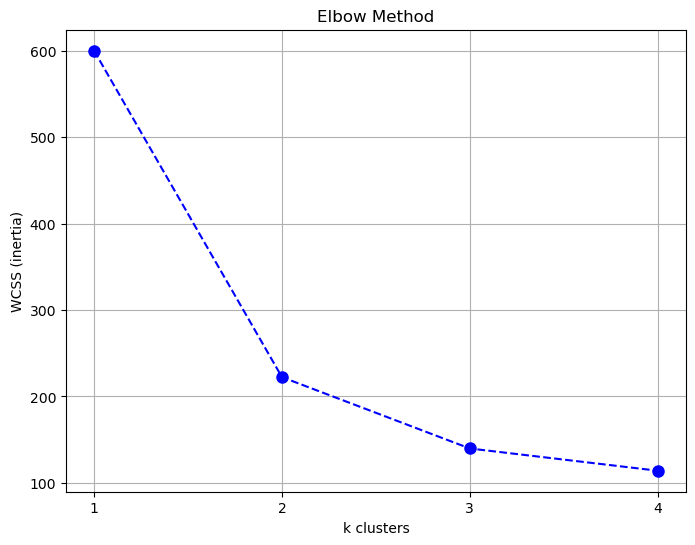

In [23]:
plt.figure(figsize=(8,6))
plt.plot(k_values,wcss,"o--",color="blue",markersize=8) #x=k y=wcss
plt.xlabel("k clusters")
plt.ylabel("WCSS (inertia)")
plt.xticks(k_values)
plt.title("Elbow Method")
plt.grid(True)
plt.show()

dal grafico k=2 anche se si già che il dataset iris ha 3 tipologie di fiore, pertanto sarebbe k=3, ma se guardiamo il grafico k=2

In [24]:
from sklearn.metrics import silhouette_score

for k in range(2,7):
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    labels = kmeans.fit_predict(X_std)
    score = silhouette_score(X_std, labels)
    print(k, score)

c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

2 0.5817500491982808
3 0.45994823920518635
4 0.38694104154427816
5 0.3459012795948778
6 0.31707940193569023


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


anche il metodo silhoutte conferma con il valore maggiore si ha con k=2  2--0.58175004919..

In [26]:
k=3
kmeans=KMeans(n_clusters=k,init="k-means++",random_state=42,n_init=10)
clusters=kmeans.fit_predict(X_std)

centroids=kmeans.cluster_centers_ #salvo i centroidi finali (avendo 13 feature nel dataset originale, ogni centroide ha 13 valori)
iter=kmeans.n_iter_  #numero di iterazoini servite per convergere

print(f"Iteration: \t{iter}")
print(f"Centroidi: \n{centroids}")

Iteration: 	4
Centroidi: 
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [27]:
pca=PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(X_std)

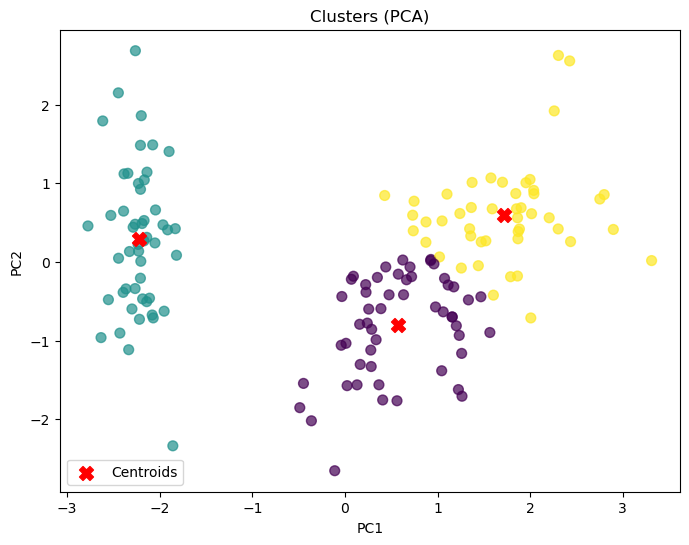

In [28]:

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters,cmap="viridis",s=50,alpha=0.7)
plt.scatter(
    pca.transform(centroids)[:,0],
    pca.transform(centroids)[:,1],
    c="red",
    s=100,
    marker="X",
    label="Centroids",
)
plt.title("Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()